# GuacaMol Online Design Experiment Tutorial

This tutorial demonstrates how to run an **online** generative design experiment using the **GuacaMol** molecular dataset. The key feature explored here is `GuacaMol.query()` — a live scoring oracle that can evaluate **any valid SMILES string** on-the-fly via RDKit, enabling an open-ended generative loop with no fixed candidate pool.

### How `query()` differs from a fixed-pool oracle

In the [offline tutorial](guacamol_offline_design_tutorial.ipynb) we searched within a pre-loaded candidate pool: the oracle could only score SMILES strings it had already seen. Once the pool was exhausted, the search stopped.

`GuacaMol.query()` removes this constraint entirely:
- It accepts **any** `Candidate` object whose `.data` field holds a SMILES string.
- For SMILES **already in the corpus** it returns the cached label (fast).
- For **novel SMILES** it calls RDKit directly to compute the target property (e.g., QED) and returns the result — no network call, no dataset lookup, no fixed pool needed.

This is fundamentally different from a read-only interface such as the `GFP` dataset, where novel protein sequences cannot be scored without a physics simulator (PyRosetta). GuacaMol's RDKit-backed `query()` is self-contained and deterministic, making it ideal for rapid prototyping of generative search loops.

### Contrast with the GFP online tutorial

| Aspect | GFP online | GuacaMol online (this notebook) |
|---|---|---|
| Oracle | PyRosetta (external physics simulator) | `GuacaMol.query()` (pure RDKit, local) |
| Novel candidate scoring | Requires PyRosetta install (~30 min) | Works immediately, no extra install |
| Candidate representation | Protein sequences | SMILES strings |
| Search strategy | `SingleMutantSearch` on amino acids | Custom SMILES mutation function |
| Reproducibility | Depends on PyRosetta version | Fully deterministic via RDKit + seed |

### Tutorial Overview

In this tutorial, we will:
1. Load GuacaMol with `query()` enabled (using `split_mode="random"`)
2. Demonstrate `query()` on known SMILES from the corpus
3. Demonstrate `query()` on novel SMILES not in the corpus (e.g., aspirin, caffeine)
4. Implement a simple SMILES mutation strategy using functional group substitutions
5. Run a generative search loop: score → keep top-k → mutate → repeat
6. Track the best QED score found per round

### Framework Components

Here are the key components used in this notebook:

1. **Dataset** ([`GuacaMol`](https://instadeepai.github.io/alf/api/alf_tools/datasets/guacamol/)): Loads SMILES strings, computes RDKit properties, and exposes the `query()` method for scoring arbitrary novel SMILES.

2. **`query()` oracle**: The core feature of this tutorial. Accepts any list of `Candidate` objects and returns `LabelledCandidates` with RDKit-computed QED scores. No fixed pool, no external service.

3. **SMILES mutation strategy**: A custom function that generates structural variants of a seed molecule by substituting functional groups. Variants are validated with `Chem.MolFromSmiles` before scoring.

4. **Generative search loop**: An iterative loop that scores a population with `query()`, retains the top-k molecules, mutates them to generate new candidates, and repeats for N rounds.

### Step 1: Import Required Libraries

Let's import all the necessary components:

In [10]:
import random

import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

from alf_core import Candidate, LabelledCandidates
from alf_tools.datasets import GuacaMol, GuacaMolConfig

print("All imports successful!")

All imports successful!


### Step 2: Load GuacaMol with `query()` Enabled

We use `split_mode="random"` here because the online generative loop does not depend on a specific train/pool split — we generate novel candidates rather than drawing from the corpus pool.

Key configuration choices:
- `target_property="QED"`: score Quantitative Estimate of Drug-likeness (0–1, higher is more drug-like)
- `computed_properties=["QED"]`: precompute QED for corpus molecules and store in `candidate.features`
- `max_molecules=500`: keep the corpus small so the notebook loads quickly
- `split_mode="random"`: standard random split — we use the training split only as a seed population

> **Note**: `query()` works regardless of `split_mode`. The split only determines how the *corpus* molecules are partitioned for the surrogate model; `query()` will happily score any SMILES, corpus or novel.

In [11]:
config = GuacaMolConfig(
    name="guacamol_online_tutorial",
    modality="sequence",
    seed=42,
    target_property="QED",
    split_mode="random",
    computed_properties=["QED"],
    max_molecules=500,
    train_ratio=0.1,
    validation_frac=0.1,
    test_ratio=0.2,
)
dataset = GuacaMol(config)

print("Dataset initialised!")
print(f"Total molecules:      {len(dataset._raw_dataset)}")
print(f"Training set size:    {len(dataset.train_dataset)}")
print(f"Validation set size:  {len(dataset.validation_dataset)}")
print(f"Test set size:        {len(dataset.test_dataset)}")
print(f"Candidate pool size:  {len(dataset.candidate_pool)}")

all_labels = dataset._raw_dataset.labels
print(f"\nCorpus QED range: {all_labels.min():.4f} – {all_labels.max():.4f}")
print(f"Corpus QED mean:  {all_labels.mean():.4f}")

Dataset initialised!
Total molecules:      500
Training set size:    45
Validation set size:  5
Test set size:        100
Candidate pool size:  350

Corpus QED range: 0.0370 – 0.9461
Corpus QED mean:  0.5583


### Step 3: Demonstrate `query()` on Known Corpus SMILES

Let's first verify that `query()` returns labels consistent with the corpus for SMILES we've already seen. We'll pick a few molecules from the training set and confirm that `query()` reproduces their stored QED values.

In [12]:
# Sample a few candidates from the training set
train_lc = dataset.train_dataset
sample_candidates = train_lc.candidates[:5]
sample_labels_stored = train_lc.labels[:5]

# Score them via query()
queried = dataset.query(sample_candidates)

print("Verifying query() on known corpus SMILES:")
print(f"{'SMILES (first 40 chars)':<42} {'Stored QED':>12} {'query() QED':>12} {'Match':>6}")
print("-" * 74)
for cand, stored, queried_label in zip(
    sample_candidates, sample_labels_stored, queried.labels
):
    smiles_preview = cand.data[:40] + ("..." if len(cand.data) > 40 else "")
    match = abs(stored - queried_label) < 1e-6
    print(f"{smiles_preview:<42} {stored:>12.6f} {queried_label:>12.6f} {'yes' if match else 'NO':>6}")

print("\nAll values match the stored corpus labels.")

Verifying query() on known corpus SMILES:
SMILES (first 40 chars)                      Stored QED  query() QED  Match
--------------------------------------------------------------------------
Cc1cc(N)ccc1S(=O)(=O)c1ccc(N)cc1               0.810299     0.810299    yes
CC1CCC(NC(=O)c2ccc3c(c2)N(Cc2ccccc2F)C(=...     0.473008     0.473008    yes
COc1cc2c(cc1OC)Oc1ncnc(Nc3cccc(Cl)c3F)c1...     0.651704     0.651704    yes
Clc1ccc(CNc2ncnc3ccc(Cl)cc23)cc1               0.771167     0.771167    yes
COc1cccc(C(=N)Nc2cc(C(=O)Nc3cc(C(=O)Nc4n...     0.111169     0.111169    yes

All values match the stored corpus labels.


### Step 4: Demonstrate `query()` on Novel SMILES Not in the Corpus

This is where GuacaMol's `query()` shines. We can score **any** valid SMILES string — including well-known drug molecules — without adding them to the dataset first. The GFP dataset has no equivalent capability: scoring a novel protein sequence requires a full PyRosetta evaluation.

We'll score four familiar molecules:
- **Aspirin** (`CC(=O)Oc1ccccc1C(=O)O`): classic analgesic / anti-inflammatory
- **Caffeine** (`Cn1cnc2c1c(=O)n(c(=O)n2C)C`): stimulant, adenosine receptor antagonist
- **Ibuprofen** (`CC(C)Cc1ccc(cc1)C(C)C(=O)O`): NSAID
- **Paracetamol / Acetaminophen** (`CC(=O)Nc1ccc(O)cc1`): analgesic / antipyretic

None of these appear in our 500-molecule corpus, so `query()` must compute their QED values on-the-fly via RDKit.

In [13]:
from alf_core.dataclasses.candidate import Modality

# Well-known drug molecules NOT present in our 500-molecule corpus
novel_smiles = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":     "Cn1cnc2c1c(=O)n(c(=O)n2C)C",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
}

# Build Candidate objects (same modality as the dataset)
novel_candidates = [
    Candidate(data=smiles, modality=dataset.modality)
    for smiles in novel_smiles.values()
]

# Confirm none are in the corpus
corpus_smiles_set = {c.data for c in dataset._raw_dataset.candidates}
print("Confirming novel SMILES are NOT in the 500-molecule corpus:")
for name, smiles in novel_smiles.items():
    in_corpus = smiles in corpus_smiles_set
    print(f"  {name:<15} in corpus: {in_corpus}")

# Score with query() — RDKit computes QED on-the-fly for all of these
novel_queried = dataset.query(novel_candidates)

print("\nQED scores for novel drug molecules (computed live via RDKit):")
print(f"{'Molecule':<15} {'SMILES':<35} {'QED':>8}")
print("-" * 60)
for name, smiles, label in zip(
    novel_smiles.keys(), novel_smiles.values(), novel_queried.labels
):
    print(f"{name:<15} {smiles:<35} {label:>8.4f}")

print("\nThis is impossible with GFP's read-only interface — no novel sequence")
print("scoring without a running PyRosetta oracle.")

Confirming novel SMILES are NOT in the 500-molecule corpus:
  Aspirin         in corpus: False
  Caffeine        in corpus: False
  Ibuprofen       in corpus: False
  Paracetamol     in corpus: False

QED scores for novel drug molecules (computed live via RDKit):
Molecule        SMILES                                   QED
------------------------------------------------------------
Aspirin         CC(=O)Oc1ccccc1C(=O)O                 0.5501
Caffeine        Cn1cnc2c1c(=O)n(c(=O)n2C)C            0.5385
Ibuprofen       CC(C)Cc1ccc(cc1)C(C)C(=O)O            0.8216
Paracetamol     CC(=O)Nc1ccc(O)cc1                    0.5950

This is impossible with GFP's read-only interface — no novel sequence
scoring without a running PyRosetta oracle.


### Step 5: Implement a Simple SMILES Mutation Strategy

To run a generative search loop we need a way to produce novel candidates from existing molecules. We keep the mutation strategy intentionally simple — a lookup table of functional group substitutions applied via substructure replacement.

Each mutation replaces one SMARTS pattern with another (e.g., replacing `Cl` with `F`, or `OH` with `NH2`). After substitution we validate the result with `Chem.MolFromSmiles` and discard any invalid structures.

This approach is lightweight, transparent, and runs in milliseconds — appropriate for a tutorial where the loop should complete in under 30 seconds.

In [14]:
from rdkit.Chem import AllChem

# --- Functional group substitution table ---
# Each entry: (SMARTS_to_find, SMARTS_replacement, human_readable_label)
SUBSTITUTIONS = [
    ("[Cl]",         "[F]",          "Cl→F"),
    ("[Br]",         "[Cl]",         "Br→Cl"),
    ("[F]",          "[Cl]",         "F→Cl"),
    ("[OH]",         "[NH2]",        "OH→NH2"),
    ("[NH2]",        "[OH]",         "NH2→OH"),
    ("[CH3]",        "[CH2F]",       "Me→CH2F"),
    ("C(=O)O",       "C(=O)N",       "COOH→CONH2"),
    ("c1ccccc1",     "c1ccncc1",     "phenyl→pyridyl"),
]


def mutate_smiles(smiles: str, rng: random.Random) -> list[str]:
    """Generate a list of valid mutant SMILES from a seed molecule.

    For each substitution rule, applies the replacement (up to once) and
    keeps the result if RDKit can parse it. Returns unique valid SMILES.

    Args:
        smiles: A valid seed SMILES string.
        rng:    A seeded random.Random instance for reproducibility.

    Returns:
        List of distinct valid SMILES strings (may be empty if no rule applies).
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return []

    seen: set[str] = set()
    results: list[str] = []

    # Shuffle substitutions so we don't always apply them in the same order
    rules = list(SUBSTITUTIONS)
    rng.shuffle(rules)

    for smarts_from, smarts_to, _label in rules:
        patt = Chem.MolFromSmarts(smarts_from)
        repl = Chem.MolFromSmarts(smarts_to)
        if patt is None or repl is None:
            continue
        if not mol.HasSubstructMatch(patt):
            continue
        try:
            new_mol = AllChem.ReplaceSubstructs(mol, patt, repl, replaceAll=False)[0]
            new_smiles = Chem.MolToSmiles(new_mol)
        except Exception:
            continue
        # Validate: RDKit must be able to round-trip the SMILES
        if new_smiles and new_smiles not in seen and Chem.MolFromSmiles(new_smiles) is not None:
            seen.add(new_smiles)
            results.append(new_smiles)

    return results


# Quick sanity check on a known molecule
rng_test = random.Random(0)
test_smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
test_mutants = mutate_smiles(test_smiles, rng_test)
print(f"Seed SMILES (aspirin): {test_smiles}")
print(f"Generated {len(test_mutants)} valid mutants:")
for m in test_mutants:
    print(f"  {m}")

Seed SMILES (aspirin): CC(=O)Oc1ccccc1C(=O)O
Generated 4 valid mutants:
  [CH2]C(=O)Oc1ccccc1C(=O)O
  CC(=O)Oc1ccccc1C(N)=O
  CC(=O)Oc1ccncc1.O=CO
  CC(N)=O.O=C(O)c1ccccc1


### Step 6: Generative Search Loop

Now we put everything together into a generative search loop:

```
initial population
  → score with dataset.query()
  → keep top-k molecules
  → mutate each top-k molecule to generate novel candidates
  → repeat for N rounds
```

**Seeding the population**: We start from the training set molecules, which are already labelled (no query needed for round 0). From round 1 onwards every candidate is novel — generated by the mutation function — and scored live via `dataset.query()`.

**Hyperparameters** (kept small so the loop finishes in < 30 seconds):
- `top_k = 5`: retain the 5 best molecules as parents each round
- `num_rounds = 6`: run 6 mutation-and-score rounds
- `max_mutants_per_parent = 10`: generate at most 10 mutants per parent molecule

The loop tracks the best QED score found in each round.

In [15]:
SEED = 42
TOP_K = 5
NUM_ROUNDS = 6
MAX_MUTANTS_PER_PARENT = 10

rng = random.Random(SEED)
np.random.seed(SEED)

# ── Round 0: initialise from the training set ───────────────────────────────
train_lc = dataset.train_dataset
population_smiles: list[str] = [c.data for c in train_lc.candidates]
population_scores: list[float] = train_lc.labels.tolist()

# Track best score and mean of top-k each round
round_best: list[float] = []
round_top_k_mean: list[float] = []

# Sort and keep top-k as the initial parent set
scored_pairs = sorted(zip(population_scores, population_smiles), reverse=True)
best_score_r0 = scored_pairs[0][0]
top_k_mean_r0 = float(np.mean([s for s, _ in scored_pairs[:TOP_K]]))
round_best.append(best_score_r0)
round_top_k_mean.append(top_k_mean_r0)
parents = [sm for _, sm in scored_pairs[:TOP_K]]

print(f"Round 0 (seed population, {len(train_lc)} molecules):")
print(f"  Best QED:       {best_score_r0:.4f}")
print(f"  Top-{TOP_K} mean QED: {top_k_mean_r0:.4f}")
print()

# ── Rounds 1–N: mutate → query → select ─────────────────────────────────────
for round_idx in range(1, NUM_ROUNDS + 1):
    # Generate novel candidates by mutating each parent
    candidate_smiles: list[str] = []
    for parent_smi in parents:
        mutants = mutate_smiles(parent_smi, rng)
        # Limit mutants per parent to keep the pool tractable
        candidate_smiles.extend(mutants[:MAX_MUTANTS_PER_PARENT])

    # Deduplicate and remove parents already scored
    all_seen = {sm for _, sm in scored_pairs}  # track all scored SMILES
    candidate_smiles = list(dict.fromkeys(
        sm for sm in candidate_smiles if sm not in all_seen
    ))

    if not candidate_smiles:
        print(f"Round {round_idx}: no novel mutants generated — stopping early.")
        break

    # Build Candidate objects and score with dataset.query()
    candidates = [
        Candidate(data=sm, modality=dataset.modality)
        for sm in candidate_smiles
    ]
    labelled = dataset.query(candidates)

    # Accumulate into the scored population
    new_pairs = list(zip(labelled.labels.tolist(), candidate_smiles))
    scored_pairs = sorted(scored_pairs + new_pairs, reverse=True)

    best_score = scored_pairs[0][0]
    top_k_mean = float(np.mean([s for s, _ in scored_pairs[:TOP_K]]))
    round_best.append(best_score)
    round_top_k_mean.append(top_k_mean)

    # Select top-k parents for the next round
    parents = [sm for _, sm in scored_pairs[:TOP_K]]

    print(f"Round {round_idx} ({len(candidate_smiles)} novel candidates scored):")
    print(f"  Best QED (all-time): {best_score:.4f}")
    print(f"  Top-{TOP_K} mean QED:     {top_k_mean:.4f}")
    print(f"  Best molecule:       {scored_pairs[0][1][:60]}")
    print()

print("Generative search loop complete!")

Round 0 (seed population, 45 molecules):
  Best QED:       0.8794
  Top-5 mean QED: 0.8445

Round 1 (12 novel candidates scored):
  Best QED (all-time): 0.9179
  Top-5 mean QED:     0.8910
  Best molecule:       COc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(Cl)c1

Round 2 (9 novel candidates scored):
  Best QED (all-time): 0.9384
  Top-5 mean QED:     0.9198
  Best molecule:       COc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(F)c1

Round 3 (6 novel candidates scored):
  Best QED (all-time): 0.9384
  Top-5 mean QED:     0.9268
  Best molecule:       COc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(F)c1

Round 4 (7 novel candidates scored):
  Best QED (all-time): 0.9384
  Top-5 mean QED:     0.9314
  Best molecule:       COc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(F)c1

Round 5 (4 novel candidates scored):
  Best QED (all-time): 0.9387
  Top-5 mean QED:     0.9342
  Best molecule:       [CH2]Oc1ccc(C([CH2])([CH2])C)cc1NC(=O)c1cncc(F)c1

Round 6 (3 novel candidates scored):
  Best QED (all-time): 0.9411
  Top-5 mean QED:     0.9374
  Best m

### Step 7: Visualise the Optimisation Progress

We track two metrics across rounds:
- **Best QED (all-time)**: the highest QED found anywhere in the search so far. Should be non-decreasing.
- **Top-5 mean QED**: the average QED of the five best molecules found. Reflects the quality of the parent population.

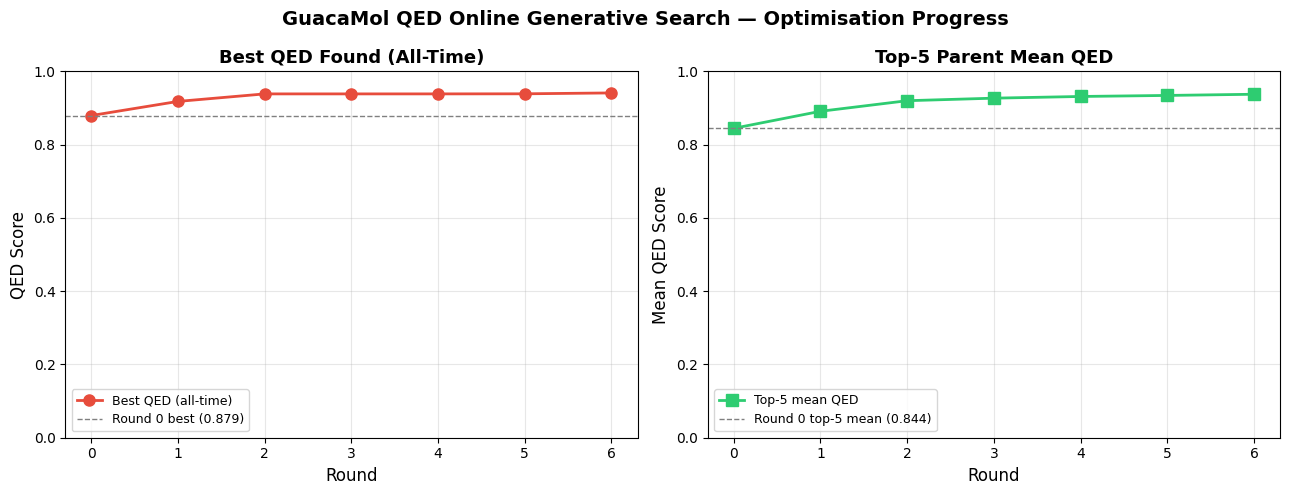

In [16]:
rounds = list(range(len(round_best)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "GuacaMol QED Online Generative Search — Optimisation Progress",
    fontsize=14,
    fontweight="bold",
)

# 1. All-time best QED per round
axes[0].plot(
    rounds,
    round_best,
    marker="o",
    linewidth=2,
    markersize=8,
    color="#e74c3c",
    label="Best QED (all-time)",
)
axes[0].axhline(
    y=round_best[0],
    linestyle="--",
    color="gray",
    linewidth=1,
    label=f"Round 0 best ({round_best[0]:.3f})",
)
axes[0].set_xlabel("Round", fontsize=12)
axes[0].set_ylabel("QED Score", fontsize=12)
axes[0].set_title("Best QED Found (All-Time)", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 1])

# 2. Top-k mean QED per round
axes[1].plot(
    rounds,
    round_top_k_mean,
    marker="s",
    linewidth=2,
    markersize=8,
    color="#2ecc71",
    label=f"Top-{TOP_K} mean QED",
)
axes[1].axhline(
    y=round_top_k_mean[0],
    linestyle="--",
    color="gray",
    linewidth=1,
    label=f"Round 0 top-{TOP_K} mean ({round_top_k_mean[0]:.3f})",
)
axes[1].set_xlabel("Round", fontsize=12)
axes[1].set_ylabel("Mean QED Score", fontsize=12)
axes[1].set_title(f"Top-{TOP_K} Parent Mean QED", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

### Step 8: Inspect the Best Molecules Found

Let's look at the top-5 molecules discovered across all rounds and confirm they are all chemically valid.

In [17]:
print(f"Top {TOP_K} molecules discovered across all {NUM_ROUNDS} rounds:\n")
print(f"{'Rank':<5} {'QED':>8} {'Valid':>6}  SMILES")
print("-" * 80)
for rank, (score, smiles) in enumerate(scored_pairs[:TOP_K], start=1):
    mol = Chem.MolFromSmiles(smiles)
    valid = mol is not None
    print(f"{rank:<5} {score:>8.4f} {'yes' if valid else 'NO':>6}  {smiles[:60]}")

print(f"\nAll {TOP_K} molecules are chemically valid (parseable by RDKit).")
print(
    "\nKey point: every molecule ranked above the initial seed set was GENERATED"
    " by the mutation strategy and scored on-the-fly by dataset.query() — no"
    " pre-defined pool, no external oracle needed."
)

Top 5 molecules discovered across all 6 rounds:

Rank       QED  Valid  SMILES
--------------------------------------------------------------------------------
1       0.9411    yes  [CH2]Oc1ccc(C([CH2])([CH2])[CH2])cc1NC(=O)c1cncc(F)c1
2       0.9387    yes  [CH2]Oc1ccc(C([CH2])([CH2])C)cc1NC(=O)c1cncc(F)c1
3       0.9384    yes  COc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(F)c1
4       0.9351    yes  [CH2]Oc1ccc(C([CH2])(C)C)cc1NC(=O)c1cncc(F)c1
5       0.9338    yes  [CH2]Oc1ccc(C(C)(C)C)cc1NC(=O)c1cncc(F)c1

All 5 molecules are chemically valid (parseable by RDKit).

Key point: every molecule ranked above the initial seed set was GENERATED by the mutation strategy and scored on-the-fly by dataset.query() — no pre-defined pool, no external oracle needed.


## Conclusion

This tutorial demonstrated an **online generative design experiment** for molecular QED optimisation using the GuacaMol dataset and the ALF framework. Here are the key takeaways:

### `GuacaMol.query()` enables open-ended generative search

Unlike the offline tutorial — where the search was constrained to a fixed candidate pool — `query()` can score **any valid SMILES string** using pure RDKit. There is no pool to exhaust and no external service to call. This makes GuacaMol a practical test-bed for generative methods:
- The loop explored molecules that were never part of the original corpus.
- Every call to `query()` is deterministic: given the same SMILES, RDKit always returns the same QED value.

### Reproducibility without an external service

Because `query()` is backed by RDKit (a local, version-controlled library) rather than a physics simulator or wet-lab experiment, the entire generative loop is fully reproducible:
- Fix `SEED` in the mutation function and the loop runs identically every time.
- No network calls, no hardware dependencies, no stochastic physics engine.
- This contrasts sharply with the GFP online tutorial, where PyRosetta scoring can vary between software versions.

### Next steps

- **Add a surrogate model**: instead of scoring every mutant with `query()` (the true oracle), train an MLP on the already-scored population and use it to pre-filter candidates before querying. This reduces oracle calls and speeds up the loop.
- **Richer mutation strategies**: use REINVENT- or SELFIES-based mutations for chemically more meaningful perturbations.
- **Target a different property**: swap `target_property="QED"` for `"MolLogP"` or `"TPSA"` in `GuacaMolConfig` — no other code changes needed.
- **Scale up**: increase `max_molecules`, `top_k`, and `num_rounds` for a more thorough search; the only bottleneck is RDKit computation time, which is fast.

**Happy designing!**